In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import session_processing_helper as helper
import utils

In [3]:
# Configuration
data_dir = '/Users/rebekahzhang/data/behavior_data'
exp = 'exp2'
data_folder = os.path.join(data_dir, exp)
output_folder = os.path.join(data_dir, 'HMM')
os.makedirs(output_folder, exist_ok=True)

In [4]:
sessions_training = utils.load_session_log(data_folder, f'sessions_training_{exp}.csv')

In [5]:
session_info = sessions_training.loc[sessions_training.dir == '2024-02-02_10-34-46_RZ036'].iloc[0]
events = utils.load_data(utils.generate_events_processed_path(data_folder, session_info))
trials = utils.load_data(utils.generate_trials_path(data_folder, session_info))
trials_data = helper.get_trial_data_df(events.groupby('session_trial_num'))
trials_analyzed = pd.merge(trials, trials_data, on='session_trial_num')

In [6]:
trials_filtered = pd.read_csv(os.path.join(data_folder, "trials_training_filtered2.csv"))

# Reward sensitivity

In [6]:
trials_filtered['delta_tw'] = trials_filtered['time_waited'] - trials_filtered['previous_trial_time_waited']
trials_filtered_not_miss = trials_filtered.loc[trials_filtered['miss_trial'] == False].copy()

DELTA TW STATISTICS BY GROUP AND PREVIOUS TRIAL REWARD

Group S:
  Unrewarded (0):
    Mean: 0.5175
    Std:  3.2482
    N:    189013
  Rewarded (5):
    Mean: -1.1706
    Std:  4.3520
    N:    97255

Group L:
  Unrewarded (0):
    Mean: 0.6868
    Std:  6.6400
    N:    183896
  Rewarded (5):
    Mean: -1.8405
    Std:  7.3148
    N:    128747


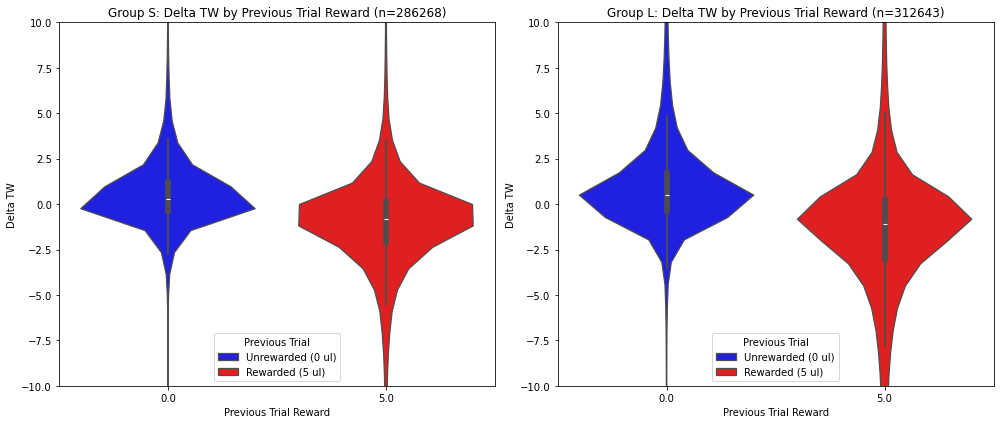

In [7]:
plot_data_clean = trials_filtered_not_miss.dropna(subset=['delta_tw', 'previous_trial_reward', 'group'])

# Get unique groups
groups = plot_data_clean['group'].unique()

# Print statistics
print("=" * 60)
print("DELTA TW STATISTICS BY GROUP AND PREVIOUS TRIAL REWARD")
print("=" * 60)
for group in groups:
    data_group = plot_data_clean[plot_data_clean['group'] == group]
    print(f"\nGroup {group.upper()}:")
    for reward in sorted(data_group['previous_trial_reward'].unique()):
        reward_data = data_group[data_group['previous_trial_reward'] == reward]
        reward_label = "Unrewarded (0)" if reward == 0 else "Rewarded (5)"
        print(f"  {reward_label}:")
        print(f"    Mean: {reward_data['delta_tw'].mean():.4f}")
        print(f"    Std:  {reward_data['delta_tw'].std():.4f}")
        print(f"    N:    {len(reward_data)}")
print("=" * 60)

# Create separate plots for each group
fig, axes = plt.subplots(1, len(groups), figsize=(7 * len(groups), 6))
if len(groups) == 1:
    axes = [axes]

# Define colors: blue for unrewarded (0), red for rewarded (5)
colors = {0: 'blue', 5: 'red'}

for idx, group in enumerate(groups):
    data_group = plot_data_clean[plot_data_clean['group'] == group]
    
    # Use violin plot for better visualization of large datasets
    sns.violinplot(data=data_group, x='previous_trial_reward', y='delta_tw', 
                   hue='previous_trial_reward', palette=colors, ax=axes[idx])
    
    axes[idx].set_xlabel('Previous Trial Reward')
    axes[idx].set_ylabel('Delta TW')
    axes[idx].set_ylim(-10, 10)
    axes[idx].set_title(f'Group {group.upper()}: Delta TW by Previous Trial Reward (n={len(data_group)})')
    
    # Customize legend
    handles, labels = axes[idx].get_legend_handles_labels()
    axes[idx].legend(handles, ['Unrewarded (0 ul)', 'Rewarded (5 ul)'], title='Previous Trial')

plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'delta_tw_by_previous_reward.png'))

In [8]:
# Create quantiles based on PREVIOUS trial's time_waited
trials_quantile = trials_filtered_not_miss.copy()

# Create quantiles of previous_trial_time_waited
trials_quantile['prev_tw_quantile'] = pd.qcut(
    trials_quantile['previous_trial_time_waited'], 
    q=4, 
    labels=['Q1 (0-25%)', 'Q2 (25-50%)', 'Q3 (50-75%)', 'Q4 (75-100%)'],
    duplicates='drop'
)

print("Previous Trial Time Waited Quantile distribution:")
print(trials_quantile['prev_tw_quantile'].value_counts().sort_index())
print(f"\nTotal rows with quantiles: {trials_quantile['prev_tw_quantile'].notna().sum()}")

Previous Trial Time Waited Quantile distribution:
Q1 (0-25%)      149728
Q2 (25-50%)     149728
Q3 (50-75%)     149727
Q4 (75-100%)    149728
Name: prev_tw_quantile, dtype: int64

Total rows with quantiles: 598911


DELTA TW BY QUANTILE, REWARD, AND GROUP

Group L:
  Q1 (0-25%): Unrewarded=1.560, Rewarded=0.844, Diff=-0.716
  Q2 (25-50%): Unrewarded=1.187, Rewarded=0.369, Diff=-0.818
  Q3 (50-75%): Unrewarded=1.113, Rewarded=-0.151, Diff=-1.264
  Q4 (75-100%): Unrewarded=-3.037, Rewarded=-3.555, Diff=-0.518

Group S:
  Q1 (0-25%): Unrewarded=1.171, Rewarded=0.581, Diff=-0.590
  Q2 (25-50%): Unrewarded=0.651, Rewarded=0.136, Diff=-0.515
  Q3 (50-75%): Unrewarded=0.072, Rewarded=-0.490, Diff=-0.562
  Q4 (75-100%): Unrewarded=-1.867, Rewarded=-2.755, Diff=-0.888


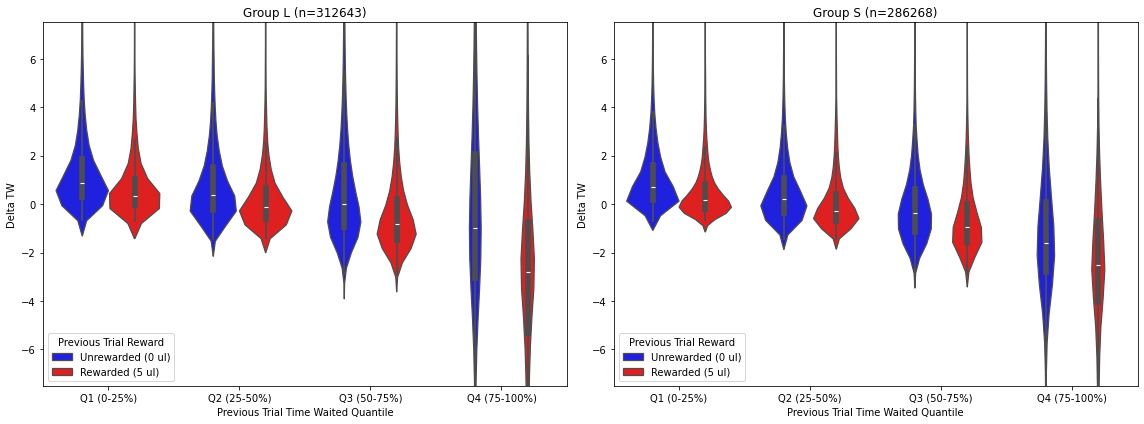

In [9]:
# Analyze all quantiles in one plot per group
plot_data_q = trials_quantile.dropna(subset=['delta_tw', 'previous_trial_reward', 'group', 'prev_tw_quantile'])

# Print condensed statistics
print("="*70)
print("DELTA TW BY QUANTILE, REWARD, AND GROUP")
print("="*70)
for group in ['l', 's']:
    print(f"\nGroup {group.upper()}:")
    data_group = plot_data_q[plot_data_q['group'] == group]
    for quantile in sorted(data_group['prev_tw_quantile'].unique()):
        q_data = data_group[data_group['prev_tw_quantile'] == quantile]
        unrewarded = q_data[q_data['previous_trial_reward'] == 0]['delta_tw'].mean()
        rewarded = q_data[q_data['previous_trial_reward'] == 5]['delta_tw'].mean()
        print(f"  {quantile}: Unrewarded={unrewarded:.3f}, Rewarded={rewarded:.3f}, Diff={rewarded-unrewarded:.3f}")

# Create combined plot: L on left, S on right
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = {0: 'blue', 5: 'red'}

for idx, group in enumerate(['l', 's']):
    data_group = plot_data_q[plot_data_q['group'] == group]
    sns.violinplot(data=data_group, x='prev_tw_quantile', y='delta_tw', 
                   hue='previous_trial_reward', palette=colors, ax=axes[idx], split=False)
    axes[idx].set_xlabel('Previous Trial Time Waited Quantile')
    axes[idx].set_ylabel('Delta TW')
    axes[idx].set_ylim(-7.5, 7.5)
    axes[idx].set_title(f'Group {group.upper()} (n={len(data_group)})')
    
    # Customize legend
    handles, labels = axes[idx].get_legend_handles_labels()
    axes[idx].legend(handles, ['Unrewarded (0 ul)', 'Rewarded (5 ul)'], title='Previous Trial Reward')

plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'delta_tw_by_prev_tw_quantile_and_reward.png'))

# HMM data prep

In [7]:
from __future__ import annotations

import os
import sys
import warnings
from dataclasses import dataclass
from typing import Dict, Tuple, List

import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM

In [14]:
N_STATES = 3
RANDOM_STATE = 0
N_ITER = 200

# Transition "stickiness": higher => states persist longer
STICKY_P = 0.97  # self-transition probability on init
MIN_VAR = 1e-4   # floor for variances to avoid numerical issues

# Feature set (engineered below)
FEATURE_COLS = [
    # engagement
    "miss_trial",                # binary 0/1

    # background inhibition/anticipation
    "bg_repeat_rate",          # continuous, with indicator
    "mean_bg_lick_phase", # continuous, with indicator

    # lick timing
    "log_time_waited_since_last_lick",
    "log_time_waited",
    "is_fast_wait",           # binary 0/1
    "log_first_lick",

    # consummatory vigor
    "log1p_num_consumption_lick",

    # reward-modulated next-trial update (split by prev outcome)
    "dlog_wait_prevR",           # delta log wait when prev reward==1 else 0
    "dlog_wait_prevU",           # delta log wait when prev reward==0 else 0
    "dlog_wait_valid",           # binary: whether delta is valid
]

# Columns required from your dataframe
REQUIRED_COLS = [
    "mouse", "session", "session_trial_num",
    "miss_trial", "reward",
    "bg_repeat_rate", "mean_bg_lick_phase",
    "time_waited", "time_waited_since_last_lick",
]


In [15]:
# -------------------------
# Utilities
# -------------------------
def _assert_required_cols(df: pd.DataFrame, cols: List[str]) -> None:
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

def _safe_log(x: pd.Series, eps: float = 1e-6) -> pd.Series:
    """Log transform with small epsilon; assumes x >= 0."""
    return np.log(np.clip(x.astype(float), eps, None))

def _robust_standardize(train_values: np.ndarray) -> Tuple[float, float]:
    """Median/MAD-based scaling; returns (center, scale)."""
    med = np.nanmedian(train_values)
    mad = np.nanmedian(np.abs(train_values - med))
    # convert MAD to robust sigma-ish; avoid zero
    scale = max(mad * 1.4826, 1e-6)
    return float(med), float(scale)

def _apply_standardize(x: np.ndarray, center: float, scale: float) -> np.ndarray:
    return (x - center) / scale

def _init_sticky_transmat(n_states: int, sticky_p: float) -> np.ndarray:
    """Initialize a sticky transition matrix."""
    if not (0 < sticky_p < 1):
        raise ValueError("sticky_p must be between 0 and 1")
    off = (1.0 - sticky_p) / (n_states - 1)
    A = np.full((n_states, n_states), off, dtype=float)
    np.fill_diagonal(A, sticky_p)
    return A

def _nan_to_num_with_indicator(x: pd.Series, fill_value: float = 0.0) -> Tuple[pd.Series, pd.Series]:
    """Return filled series and indicator (1 if originally non-NaN, else 0)."""
    ind = (~x.isna()).astype(int)
    filled = x.fillna(fill_value)
    return filled, ind

In [16]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Engineer features for HMM (Round 2 feature list). Modifies df in place."""
    _assert_required_cols(df, REQUIRED_COLS)
    df["miss_trial"] = df["miss_trial"].astype(int)

    # Handle miss trials: set timing features to NaN (we'll fill engineered features later)
    for col in ["time_waited", "time_waited_since_cue_on", "time_waited_since_last_lick"]:
        df.loc[df["miss_trial"] == 1, col] = np.nan

    # ---- B) Background inhibition ----
    df["bg_repeat_rate"] = df["bg_repeat_rate"].astype(float)
    df["mean_bg_lick_phase"] = df["mean_bg_lick_phase"].astype(float)

    # ---- C) Impulsive/reflex lick marker in wait period ----
    df["is_fast_wait"] = ((df["time_waited"] < 0.5) & (df["miss_trial"] == 0)).astype(int)

    # ---- D) Timing + motor carryover ----
    df["log_time_waited"] = _safe_log(df["time_waited"])
    df["log_time_waited_since_last_lick"] = _safe_log(df["time_waited_since_last_lick"])
    df["log_first_lick"] = _safe_log(df["first_lick"])

    # ---- E) Consummatory vigor ----
    df["log1p_num_consumption_lick"] = np.log1p(df["num_consumption_lick"].fillna(0).astype(float))

    # ---- F) Reward-dependent update (your hypothesis) ----
    df["dlog_wait"] = (
        df["log_time_waited"] -
        df.groupby(["mouse", "session"])["log_time_waited"].shift(1)
    )

    # Valid only if current + previous trials are not missed and previous reward is known
    # Your reward coding: 5 = rewarded, 0 = unrewarded
    valid_delta = (
        (df["miss_trial"] == 0) &
        (df["previous_trial_miss_trial"] == 0) &
        (~df["previous_trial_reward"].isna())
    )
    df["dlog_wait_valid"] = valid_delta.astype(int)

    # Split delta by previous outcome; invalid -> 0
    df["dlog_wait_prevR"] = 0.0
    df["dlog_wait_prevU"] = 0.0

    mask = valid_delta
    df.loc[mask & (df["previous_trial_reward"] == 5), "dlog_wait_prevR"] = df.loc[
        mask & (df["previous_trial_reward"] == 5), "dlog_wait"
    ].astype(float)
    df.loc[mask & (df["previous_trial_reward"] == 0), "dlog_wait_prevU"] = df.loc[
        mask & (df["previous_trial_reward"] == 0), "dlog_wait"
    ].astype(float)

    # ---- Fill NaNs for HMM-consumed engineered features ----
    # Keep miss_trial / is_fast_wait / dlog_wait_valid as numeric indicators.
    fill_zero_cols = [
        "bg_repeat_rate",
        "mean_bg_lick_phase",
        "log_time_waited",
        "log_time_waited_since_last_lick",
        "log1p_num_consumption_lick",
        "dlog_wait_prevR",
        "dlog_wait_prevU",
    ]
    for c in fill_zero_cols:
        df[c] = df[c].fillna(0.0)

    return df

In [ ]:
# -------------------------
# Model fitting per mouse
# -------------------------
@dataclass
class MouseModelResult:
    mouse: str
    model: GaussianHMM
    state_map: Dict[int, str]  # numeric state -> semantic label


def fit_hmm_per_mouse(df: pd.DataFrame) -> Tuple[pd.DataFrame, Dict[str, MouseModelResult]]:
    """
    Fits a 3-state sticky Gaussian HMM per mouse, pooling all sessions for that mouse.
    Standardization is done per mouse across all its sessions (robust median/MAD).
    """
    results: Dict[str, MouseModelResult] = {}
    out = df.copy()

    for mouse, d in df.groupby("mouse", sort=False):
        d = d.copy()
        X = d[FEATURE_COLS].astype(float).to_numpy()

        # Robust standardization per mouse on continuous-ish features
        # We'll standardize ALL columns except strict binaries.
        # Binaries: miss_trial, has_bg_violation, dlog_wait_valid
        bin_cols = {"miss_trial", "has_bg_violation", "dlog_wait_valid"}
        cont_idx = [i for i, c in enumerate(FEATURE_COLS) if c not in bin_cols]

        Xz = X.copy()
        for j in cont_idx:
            center, scale = _robust_standardize(Xz[:, j])
            Xz[:, j] = _apply_standardize(Xz[:, j], center, scale)

        # For binaries, keep as 0/1 (optionally center them too; not necessary)
        # Initialize HMM
        model = GaussianHMM(
            n_components=N_STATES,
            covariance_type="diag",
            n_iter=N_ITER,
            random_state=RANDOM_STATE,
            verbose=False,
            init_params="mc",   # only init means/covars; we set startprob/transmat
            params="stmc",      # train everything
        )

        model.startprob_ = np.full(N_STATES, 1.0 / N_STATES)
        model.transmat_ = _init_sticky_transmat(N_STATES, STICKY_P)

        # Fit
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model.fit(Xz)

        # Decode
        states = model.predict(Xz)  # Viterbi
        post = model.predict_proba(Xz)  # posterior p(state|obs)

        d_out = d.copy()
        d_out["hmm_state"] = states
        for k in range(N_STATES):
            d_out[f"hmm_p{k}"] = post[:, k]

        # Label states semantically using simple signatures
        # Compute summary per numeric state on original-scale helpful columns
        summ = (
            d_out.groupby("hmm_state")
                 .agg(
                     miss_rate=("miss_trial", "mean"),
                     mean_bg_rep=("bg_repeats", "mean"),
                     mean_wait=("time_waited", "mean"),
                     mean_tsl=("time_waited_since_last_lick", "mean"),
                     mean_phase=("mean_bg_lick_phase", "mean"),
                 )
        )

        # Heuristic labeling:
        # disengaged = highest miss_rate
        disengaged_state = int(summ["miss_rate"].idxmax())

        remaining = [s for s in range(N_STATES) if s != disengaged_state]
        # impulsive = among remaining, highest bg repeats and/or lowest wait
        # We'll score impulsive by z-scored combo: +bg_repeats -mean_wait
        # (handle NaN mean_wait if many misses)
        score = {}
        for s in remaining:
            bg = float(summ.loc[s, "mean_bg_rep"])
            mw = float(summ.loc[s, "mean_wait"]) if pd.notna(summ.loc[s, "mean_wait"]) else np.inf
            score[s] = bg - 0.5 * mw  # weight wait modestly
        impulsive_state = max(score, key=score.get)

        engaged_state = [s for s in remaining if s != impulsive_state][0]

        state_map = {
            disengaged_state: "disengaged",
            impulsive_state: "impulsive",
            engaged_state: "engaged",
        }

        d_out["hmm_state_label"] = d_out["hmm_state"].map(state_map)

        # Write back into output dataframe
        out.loc[d_out.index, ["hmm_state", "hmm_state_label"]] = d_out[["hmm_state", "hmm_state_label"]]
        for k in range(N_STATES):
            out.loc[d_out.index, f"hmm_p{k}"] = d_out[f"hmm_p{k}"]

        results[str(mouse)] = MouseModelResult(mouse=str(mouse), model=model, state_map=state_map)

        print(f"[mouse={mouse}] done. state_map={state_map}")
        print(summ)

    return out, results

In [18]:
#!/usr/bin/env python3
from __future__ import annotations

import os
import warnings
from dataclasses import dataclass
from typing import Dict, Tuple, List

import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM

# =========================
# CONFIG
# =========================
N_STATES = 3
RANDOM_STATE = 0
N_ITER = 200

# Transition "stickiness": higher => states persist longer
STICKY_P = 0.97  # self-transition probability on init
MIN_VAR = 1e-4   # covariance floor for numerical stability

# Feature set (engineered below)
FEATURE_COLS = [
    # A) engagement / lapse
    "miss_trial",  # binary 0/1

    # B) background inhibition/anticipation
    "bg_repeat_rate",       # continuous (bg_repeats/bg_length)
    "mean_bg_lick_phase",   # continuous (within-attempt normalized)

    # C) impulsive / reflex lick marker in wait period
    "is_fast_wait",         # binary 0/1 (time_waited < 0.5)

    # D) timing + motor carryover
    "log_time_waited",                  # continuous
    "log_time_waited_since_last_lick",  # continuous

    # (Optional extra you included)
    "log_first_lick",        # continuous

    # E) consummatory vigor
    "log1p_num_consumption_lick",  # continuous

    # F) reward-modulated next-trial update (split by prev outcome)
    "dlog_wait_prevR",  # delta log wait when prev reward==5 else 0
    "dlog_wait_prevU",  # delta log wait when prev reward==0 else 0
    "dlog_wait_valid",  # binary: whether delta is valid
]

# Columns required from your raw dataframe (pre-engineering)
REQUIRED_COLS = [
    "mouse", "session", "session_trial_num",
    "miss_trial",
    "bg_repeats", "bg_length", "mean_bg_lick_phase",
    "time_waited", "time_waited_since_last_lick",
    "first_lick",
    "num_consumption_lick",
    "previous_trial_miss_trial", "previous_trial_reward",
]

# =========================
# Utilities
# =========================
def _assert_required_cols(df: pd.DataFrame, cols: List[str]) -> None:
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

def _safe_log(x: pd.Series, eps: float = 1e-6) -> pd.Series:
    """Log transform with small epsilon; assumes x >= 0 (NaNs preserved)."""
    x = x.astype(float)
    return np.log(np.clip(x, eps, None))

def _robust_standardize(train_values: np.ndarray) -> Tuple[float, float]:
    """Median/MAD-based scaling; returns (center, scale)."""
    med = np.nanmedian(train_values)
    mad = np.nanmedian(np.abs(train_values - med))
    scale = max(mad * 1.4826, 1e-6)  # MAD -> robust sigma; avoid zero
    return float(med), float(scale)

def _apply_standardize(x: np.ndarray, center: float, scale: float) -> np.ndarray:
    return (x - center) / scale

def _init_sticky_transmat(n_states: int, sticky_p: float) -> np.ndarray:
    """Initialize a sticky transition matrix."""
    if not (0 < sticky_p < 1):
        raise ValueError("sticky_p must be between 0 and 1")
    off = (1.0 - sticky_p) / (n_states - 1)
    A = np.full((n_states, n_states), off, dtype=float)
    np.fill_diagonal(A, sticky_p)
    return A

# =========================
# Feature engineering
# =========================
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Engineer features for HMM (Round 2 feature list).
    Returns a NEW dataframe (does not mutate caller).
    """
    _assert_required_cols(df, REQUIRED_COLS)
    df = df.copy()

    # Sort to make session-wise shifts correct
    df.sort_values(["mouse", "session", "session_trial_num"], inplace=True)

    # Ensure binary
    df["miss_trial"] = df["miss_trial"].astype(int)

    # Mask timing-like columns on missed trials
    for col in ["time_waited", "time_waited_since_last_lick", "first_lick"]:
        df.loc[df["miss_trial"] == 1, col] = np.nan

    # ---- B) Background inhibition ----
    bg_len = df["bg_length"].astype(float)
    bg_rep = df["bg_repeats"].fillna(0).astype(float)
    df["bg_repeat_rate"] = np.where((bg_len > 0) & np.isfinite(bg_len), bg_rep / bg_len, 0.0)

    df["mean_bg_lick_phase"] = df["mean_bg_lick_phase"].astype(float)
    # If mean phase is NaN for no-violation trials, keep NaN for now; we'll fill later.

    # ---- C) Impulsive/reflex lick marker in wait period ----
    df["is_fast_wait"] = ((df["time_waited"] < 0.5) & (df["miss_trial"] == 0)).astype(int)

    # ---- D) Timing + motor carryover ----
    df["log_time_waited"] = _safe_log(df["time_waited"])
    df["log_time_waited_since_last_lick"] = _safe_log(df["time_waited_since_last_lick"])
    df["log_first_lick"] = _safe_log(df["first_lick"])

    # ---- E) Consummatory vigor ----
    df["log1p_num_consumption_lick"] = np.log1p(df["num_consumption_lick"].fillna(0).astype(float))

    # ---- F) Reward-dependent update (your hypothesis) ----
    # Delta log wait (current - previous) within session
    df["dlog_wait"] = (
        df["log_time_waited"] -
        df.groupby(["mouse", "dir", "block_num"])["log_time_waited"].shift(1)
    )

    # Valid only if current + previous trials are not missed and previous reward is known
    # Reward coding in your dataset: rewarded == 5, unrewarded == 0
    valid_delta = (
        (df["miss_trial"] == 0) &
        (df["previous_trial_miss_trial"] == 0) &
        (~df["previous_trial_reward"].isna())
    )
    df["dlog_wait_valid"] = valid_delta.astype(int)

    df["dlog_wait_prevR"] = 0.0
    df["dlog_wait_prevU"] = 0.0

    mask = valid_delta
    df.loc[mask & (df["previous_trial_reward"] == 5), "dlog_wait_prevR"] = df.loc[
        mask & (df["previous_trial_reward"] == 5), "dlog_wait"
    ].astype(float)
    df.loc[mask & (df["previous_trial_reward"] == 0), "dlog_wait_prevU"] = df.loc[
        mask & (df["previous_trial_reward"] == 0), "dlog_wait"
    ].astype(float)

    # ---- Fill NaNs for HMM-consumed engineered features ----
    # Note: we fill mean_bg_lick_phase with 0.0 when undefined (often bg_repeats==0)
    fill_zero_cols = [
        "bg_repeat_rate",
        "mean_bg_lick_phase",
        "log_time_waited",
        "log_time_waited_since_last_lick",
        "log_first_lick",
        "log1p_num_consumption_lick",
        "dlog_wait_prevR",
        "dlog_wait_prevU",
    ]
    for c in fill_zero_cols:
        df[c] = df[c].fillna(0.0)

    # dlog_wait_valid, miss_trial, is_fast_wait should already be numeric
    df["dlog_wait_valid"] = df["dlog_wait_valid"].fillna(0).astype(int)

    return df

# =========================
# Model fitting per mouse
# =========================
@dataclass
class MouseModelResult:
    mouse: str
    model: GaussianHMM
    state_map: Dict[int, str]  # numeric state -> semantic label

def fit_hmm_per_mouse(df: pd.DataFrame) -> Tuple[pd.DataFrame, Dict[str, MouseModelResult]]:
    """
    Fits a 3-state sticky Gaussian HMM per mouse, pooling all sessions for that mouse.
    IMPORTANT: uses `lengths` so transitions do NOT cross session boundaries.
    Standardization is done per mouse across all its sessions (robust median/MAD).
    """
    results: Dict[str, MouseModelResult] = {}
    out = df.copy()

    # sanity
    missing_feats = [c for c in FEATURE_COLS if c not in out.columns]
    if missing_feats:
        raise ValueError(f"Missing engineered feature columns: {missing_feats}")

    for mouse, d in out.groupby("mouse", sort=False):
        # ---- within the mouse loop ----
        d = d.copy()
        d.sort_values(["dir", "block_num", "block_trial_num"], inplace=True)

        # Build lengths per (dir, block_num) so sequences don't connect across blocks
        seq_sizes = d.groupby(["dir", "block_num"], sort=False).size().to_numpy()
        lengths = seq_sizes.tolist()

        X = d[FEATURE_COLS].astype(float).to_numpy()

        post = model.predict_proba(Xz, lengths=lengths)

        # Robust standardization per mouse on continuous-ish features
        # Binaries: miss_trial, is_fast_wait, dlog_wait_valid
        bin_cols = {"miss_trial", "is_fast_wait", "dlog_wait_valid"}
        cont_idx = [i for i, c in enumerate(FEATURE_COLS) if c not in bin_cols]

        Xz = X.copy()
        for j in cont_idx:
            center, scale = _robust_standardize(Xz[:, j])
            Xz[:, j] = _apply_standardize(Xz[:, j], center, scale)

        # Initialize HMM
        model = GaussianHMM(
            n_components=N_STATES,
            covariance_type="diag",
            n_iter=N_ITER,
            random_state=RANDOM_STATE,
            verbose=False,
            init_params="mc",   # init means/covars only; we set startprob/transmat
            params="stmc",      # train startprob/transmat/means/covars
            min_covar=MIN_VAR,
        )
        model.startprob_ = np.full(N_STATES, 1.0 / N_STATES)
        model.transmat_ = _init_sticky_transmat(N_STATES, STICKY_P)

        # Fit with lengths so sequences don't connect across sessions
        model.fit(Xz, lengths=lengths)
        states = model.predict(Xz, lengths=lengths)
        post = model.predict_proba(Xz, lengths=lengths)

        d_out = d.copy()
        d_out["hmm_state"] = states
        for k in range(N_STATES):
            d_out[f"hmm_p{k}"] = post[:, k]

        # Label states semantically using simple signatures
        # (Use raw columns that exist; not engineered-only)
        summ = (
            d_out.groupby("hmm_state")
                 .agg(
                     miss_rate=("miss_trial", "mean"),
                     mean_bg_repeat_rate=("bg_repeat_rate", "mean"),
                     mean_fast_wait=("is_fast_wait", "mean"),
                     mean_wait=("time_waited", "mean"),
                     mean_tsl=("time_waited_since_last_lick", "mean"),
                     mean_phase=("mean_bg_lick_phase", "mean"),
                     mean_cons_lick=("num_consumption_lick", "mean"),
                 )
        )

        # disengaged = highest miss_rate
        disengaged_state = int(summ["miss_rate"].idxmax())

        remaining = [s for s in range(N_STATES) if s != disengaged_state]

        # impulsive among remaining: high fast_wait + high bg_repeat_rate + short time-since-last-lick
        # Use a simple composite score (higher => more impulsive)
        score = {}
        for s in remaining:
            fast = float(summ.loc[s, "mean_fast_wait"])
            bgr = float(summ.loc[s, "mean_bg_repeat_rate"])
            tsl = float(summ.loc[s, "mean_tsl"]) if pd.notna(summ.loc[s, "mean_tsl"]) else np.inf
            # Smaller tsl => more impulsive; invert it safely
            inv_tsl = 1.0 / max(tsl, 1e-3) if np.isfinite(tsl) else 0.0
            score[s] = 1.5 * fast + 1.0 * bgr + 0.5 * inv_tsl

        impulsive_state = max(score, key=score.get)
        engaged_state = [s for s in remaining if s != impulsive_state][0]

        state_map = {
            disengaged_state: "disengaged",
            impulsive_state: "impulsive",
            engaged_state: "engaged",
        }
        d_out["hmm_state_label"] = d_out["hmm_state"].map(state_map)

        # Write back into out by index
        out.loc[d_out.index, "hmm_state"] = d_out["hmm_state"]
        out.loc[d_out.index, "hmm_state_label"] = d_out["hmm_state_label"]
        for k in range(N_STATES):
            out.loc[d_out.index, f"hmm_p{k}"] = d_out[f"hmm_p{k}"]

        results[str(mouse)] = MouseModelResult(mouse=str(mouse), model=model, state_map=state_map)

        print(f"[mouse={mouse}] done. state_map={state_map}")
        print(summ)

    return out, results

# =========================
# Main
# =========================
df_feat = engineer_features(trials_filtered)
df_out, model_results = fit_hmm_per_mouse(df_feat)

output_csv = os.path.join(output_folder, "trials_with_hmm_states.csv")
df_out.to_csv(output_csv, index=False)
print(f"\nWrote: {output_csv}")

# Quick peek: reward-split delta means per state (in standardized space)
feat_to_idx = {c: i for i, c in enumerate(FEATURE_COLS)}
iR = feat_to_idx["dlog_wait_prevR"]
iU = feat_to_idx["dlog_wait_prevU"]

print("\n=== Quick peek: state means for reward-split delta features (per mouse, standardized space) ===")
for mouse, res in model_results.items():
    means = res.model.means_
    print(f"\nMouse {mouse} state_map={res.state_map}")
    for s in range(N_STATES):
        print(f"  state {s}: mean(dlog_prevR)={means[s, iR]: .3f}, mean(dlog_prevU)={means[s, iU]: .3f}")


UnboundLocalError: local variable 'model' referenced before assignment